# Transitions

## What this notebook does

This notebook constructs a **SOC2018-level transition network** from **IPUMS occupational flows (2020–2024)** and enriches it with **geometry and task-structure features** derived from your **O*NET-based occupation space run exports**.

### Inputs and global knobs

* Sets edge-selection controls: a probability threshold `P_THRESHOLD` and per-source cap `TOP_K`, plus an optional sensitivity grid over `(threshold, top-k)`.
* Loads required IPUMS transition data from `data/ipums/transitions_20_24.csv`.
* Loads O*NET run exports from `RP.exports`:

  * `occupation_embeddings_polar_scaled.csv` (occupation centroids in polar coordinates),
  * `task_embeddings_polar_scaled.csv` (task points in polar coordinates).

### Normalisation and geometry utilities

* Normalizes O*NET codes and SOC2018 codes, including O*NET detailed → SOC2018 mapping (e.g., `35-9031.00 → 35-9031`).
* Provides polar/Cartesian conversions and weighted statistics (weighted mean, weighted quantiles, weighted ECDF).

### SOC node geometry (from O*NET occupations)

* Converts O*NET occupation coordinates `(xi, chi)` to Cartesian `(x, y)`.
* Aggregates **SOC centroids** using a **robust median in (x, y)** over all O*NET detailed occupations mapped to each SOC2018, and stores both `(x_soc, y_soc)` and `(xi_soc, chi_soc)` plus support counts.

### SOC task-radius statistics (all vs core tasks)

* Converts tasks to Cartesian coordinates and (optionally) filters to **core tasks** (`is_core=True`).
* Computes **task distance to its occupation center** at the O*NET detailed level, then aggregates robustly to SOC:

  * `med_task_dist`: median task distance (SOC-level),
  * `tau_task_dist`: median of a high quantile (at `τ = 1 - e^{-1}`) of task distances,
  * plus counts (`n_tasks`, `n_onet_detailed_used`).
* Selects which task policy to use for normalization via `TASK_POLICY_FOR_U`.

### IPUMS transition matrix construction

* Aggregates IPUMS flows into a raw SOC→SOC flow matrix `F` (weighted by `WTFINL`) and row-normalizes it into a probability matrix `P`.
* Saves intermediate artifacts:

  * `ipums_transition_matrix_soc2018.npy` (row-stochastic `P`),
  * `ipums_soc2018_index.csv` (id ↔ SOC2018 index mapping).

### SOC “manual” node table (enrichment for downstream use)

Builds a consolidated SOC table containing:

* inbound/outbound transition totals (and `log1p` transforms),
* SOC geometry (`xi_soc`, `chi_soc`, support counts),
* SOC task stats (median task distance, etc.),
* dominant Job Family (if present in run exports),
* best-effort SOC labels from O*NET Occupation Data.
  Exports as `ipums_soc2018_manual.csv`.

### Transition edge table with distances and normalized hop length

* Defines a **SOC pool** requiring coverage in: IPUMS ids, SOC geometry, and task stats.
* For each source SOC:

  * selects outgoing targets with `P(src→tgt) > P_THRESHOLD`,
  * keeps at most `TOP_K` highest-probability edges,
  * computes:

    * `d_xy`: Euclidean distance between SOC centroids in occupation space,
    * `u`: normalized hop length `u = d_xy / med_src_task_dist`.
* Produces `df_tr_u` with edge metadata and selection parameters.

### Distributional diagnostics and figures (weighted by transition probability)

* Computes weighted ECDFs and weighted quantiles for `d_xy` and `u` using weights `wP`.
* Saves two standalone figures:

  * `ecdf_hoplength_abs_weighted.pdf` (ECDF of `d_xy`),
  * `ecdf_hoplength_norm_weighted.pdf` (ECDF of `u`).

### Signed overlap vs hop length (task-radius overlap analysis)

* Recomputes SOC centroids and robust SOC task radii (`r_med`) and merges them onto transition edges.
* Defines **signed overlap** between SOC task-balls:

  * `overlap_signed = r_src + r_tgt − d_centers`,
  * normalized by source radius: `overlap_norm_src = overlap_signed / r_src`.
* Evaluates association between `overlap_norm_src` and hop length `u` (unweighted and weighted Pearson), plots:

  * scatter with OLS trend (`overlap_vs_hop_u.(png|pdf)`),
  * weighted CDF of `overlap_norm_src` (`overlap_cdf.(png|pdf)`).

### Transition quality KPIs and sensitivity

* Computes global weighted KPIs (transport cost `Σ wP·d`, weighted moments/quantiles of `d` and `u`, shares of weight under `u≤1/2/3`, and Spearman correlations between distance/weight).
* Writes `transition_quality_kpis.json`.
* Optionally runs the sensitivity grid and exports `transition_sensitivity_kpis.csv`.

### Plot-interface exports

Exports lightweight files for downstream network/plot tooling:

* `plot_nodes.csv`: SOC nodes with `node_id, xi, chi` (and optional support),
* `plot_edges.csv`: SOC edges with `src_id, tgt_id, weight` plus optional diagnostics (`d_xy`, `u`, etc.),
* `plot_meta.json`: minimal metadata contract.


In [1]:
# === Cell 0: Setup (activate run, load config, constants) ===
import importlib
import numpy as np
import pandas as pd
import infra
import embeddings
import onet

importlib.reload(infra)
importlib.reload(embeddings)

infra.activate_last_run(echo=False)
RP, cfg, ENCODER_SPEC = infra.load_embeddings_run(strict=True)

SEED = 42
np.random.seed(SEED)

YEAR         = int(cfg.get("year", 2025))
ONET_VERSION = str(cfg.get("onet_version", "30_0"))
ENCODER_NAME = str(cfg.get("encoder_name", "")).strip()

print("RUN_TAG   :", infra.RUN_TAG)
print("RUN_DIR   :", infra.RUN_DIR)
print("Exports   :", RP.exports)
print("YEAR      :", YEAR)
print("ONET_VER  :", ONET_VERSION)
print("ENCODER   :", ENCODER_NAME)
print("ENCODER_ID:", ENCODER_SPEC.embedder_id())
print("SEED      :", SEED)

db = onet.get_db(version=ONET_VERSION)
infra.log(f"O*NET DB: {db.db_dir} (version={db.version})")


RUN_TAG   : embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1
RUN_DIR   : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1
Exports   : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports
YEAR      : 2025
ONET_VER  : 30_1
ENCODER   : openai-3-large
ENCODER_ID: openai:text-embedding-3-large?dim=3072
SEED      : 42
• O*NET DB: /home/joc/code/geometry-of-work/data/onet/db_30_1 (version=30.1)


In [2]:
# === Cell 1: Notebook config (analysis knobs) ===
P_THRESHOLD = 0.001
TOP_K       = 25

# optional sensitivity grid (set to [] to skip)
SENS_GRID = [
    (1e-4, 3),
    (5e-4, 3),
    (1e-3, 3),
    (2e-3, 3),
    (1e-3, 1),
    (1e-3, 5),
    (1e-3, 10),
]

TASK_POLICY_VARIANTS = ["all", "core"]   # "core" uses is_core=True
TASK_POLICY_FOR_U    = "all"            # choose "all" or "core"

# Robust centroid: median in x/y (fixed by design)
CENTROID_METHOD = "median_xy"


In [3]:
# === Cell 2: Data paths (IPUMS transitions) ===
from pathlib import Path

DATA_DIR   = RP.project_root / "data"
IPUMS_DIR  = DATA_DIR / "ipums"

PATH_IPUMS = IPUMS_DIR / "transitions_20_24.csv"
if not PATH_IPUMS.exists():
    raise FileNotFoundError(f"Hittar inte fil: {PATH_IPUMS}")

infra.log("Paths OK:", PATH_IPUMS)


• Paths OK: /home/joc/code/geometry-of-work/data/ipums/transitions_20_24.csv


In [4]:
# === Cell 3: Core helpers (normalisation, geometry, weighted stats) ===
import re

def norm_onet_full(s):
    if pd.isna(s):
        return np.nan
    return str(s).strip().upper().split()[0]  # keep decimal

def norm_soc2018(s):
    # Accept "35-9031", "359031", etc -> "35-9031"
    d = re.sub(r"\D", "", str(s))[:6].rjust(6, "0")
    return f"{d[:2]}-{d[2:]}"

def onet_full_to_soc2018(onet_full: str):
    # "35-9031.00" -> "35-9031"
    if onet_full is None or pd.isna(onet_full):
        return np.nan
    s = str(onet_full).strip()
    s = s.split()[0]
    s = s.split(".")[0]
    return norm_soc2018(s)

def polar_to_xy(xi, chi):
    # xi is radians by contract
    xi  = np.asarray(xi, float)
    chi = np.asarray(chi, float)
    return chi * np.cos(xi), chi * np.sin(xi)

def xy_to_polar(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    chi = np.hypot(x, y)
    xi  = (np.arctan2(y, x) + 2*np.pi) % (2*np.pi)
    return xi, chi

def wmask(x, w):
    x = np.asarray(x, float)
    w = np.asarray(w, float)
    m = np.isfinite(x) & np.isfinite(w) & (w > 0)
    return x[m], w[m]

def wmean(x, w):
    x, w = wmask(x, w)
    return float(np.sum(w * x) / np.sum(w)) if x.size else np.nan

def wquantile(x, w, q):
    x, w = wmask(x, w)
    if x.size == 0:
        return np.nan
    o = np.argsort(x)
    xs, ws = x[o], w[o]
    cw = np.cumsum(ws) / ws.sum()
    return float(np.interp(q, cw, xs))

def weighted_ecdf(x, w):
    x, w = wmask(x, w)
    if x.size == 0:
        return np.array([]), np.array([])
    o = np.argsort(x)
    x, w = x[o], w[o]
    xu, inv = np.unique(x, return_inverse=True)
    wsum = np.zeros_like(xu, dtype=float)
    np.add.at(wsum, inv, w)
    cw = np.cumsum(wsum)
    cdf = cw / cw[-1]
    return xu, cdf


In [5]:
# === Cell 4: Load run exports (occupations + tasks) ===
def load_occ_from_run() -> pd.DataFrame:
    occ_fp = RP.exports / "occupation_embeddings_polar_scaled.csv"
    if not occ_fp.exists():
        raise FileNotFoundError(f"Missing run export: {occ_fp}")
    df = infra.read_csv_any(occ_fp)
    need = {"onet_code", "xi", "chi"}
    miss = sorted(need - set(df.columns))
    if miss:
        raise ValueError(f"occupation export missing columns: {miss}")

    keep = ["onet_code", "xi", "chi"]
    for c in ["Title", "Job Family", "sector_zone"]:
        if c in df.columns:
            keep.append(c)
    out = df[keep].copy()
    out["onet_code"] = out["onet_code"].astype("string").str.strip()
    out["onet_full"] = out["onet_code"].map(norm_onet_full)
    return out.dropna(subset=["onet_full", "xi", "chi"]).drop_duplicates("onet_full").reset_index(drop=True)

def load_tasks_from_run() -> pd.DataFrame:
    task_fp = RP.exports / "task_embeddings_polar_scaled.csv"
    if not task_fp.exists():
        raise FileNotFoundError(f"Missing run export: {task_fp}")
    df = infra.read_csv_any(task_fp)
    need = {"onet_code", "xi", "chi"}
    miss = sorted(need - set(df.columns))
    if miss:
        raise ValueError(f"task export missing columns: {miss}")

    keep = ["onet_code", "xi", "chi"]
    for c in ["Task ID", "Task", "is_core"]:
        if c in df.columns:
            keep.append(c)

    out = df[keep].copy()
    out["onet_code"] = out["onet_code"].astype("string").str.strip()
    out["onet_full"] = out["onet_code"].map(norm_onet_full)

    # Dedupe tasks per onet_full
    if "Task ID" in out.columns:
        out = out.drop_duplicates(subset=["onet_full", "Task ID"])
    else:
        out = out.drop_duplicates(subset=["onet_full", "xi", "chi"])

    return out.dropna(subset=["onet_full", "xi", "chi"]).reset_index(drop=True)

df_occ = load_occ_from_run()
df_tasks = load_tasks_from_run()

infra.log("df_occ  :", df_occ.shape)
infra.log("df_tasks:", df_tasks.shape)

display(df_occ.head(3))
display(df_tasks.head(3))


• df_occ  : (878, 7)
• df_tasks: (17606, 7)


,onet_code,xi,chi,Title,Job Family,sector_zone,onet_full
0,11-1011.00,0.043673,0.428394,Chief Executives,Management,00-Z2,11-1011.00
1,11-1011.03,0.732712,0.569120,Chief Sustainability Officers,Management,04-Z2,11-1011.03
2,11-1021.00,6.011102,0.224708,General and Operations Managers,Management,34-Z1,11-1021.00


,onet_code,xi,chi,Task ID,Task,is_core,onet_full
0,11-1011.00,5.887743,0.287446,8823,Direct or coordinate an organization's financi...,True,11-1011.00
1,11-1011.00,6.121573,0.599159,8824,"Confer with board members, organization offici...",True,11-1011.00
2,11-1011.00,0.177955,0.345124,8827,"Prepare budgets for approval, including those ...",True,11-1011.00


In [6]:
# === Cell 5: Build SOC2018 geometry tables (SOC nodes in xy/polar) ===
# O*NET detailed -> xy
df_occ_onet = df_occ[["onet_full", "xi", "chi"] + [c for c in ["Title", "Job Family", "sector_zone"] if c in df_occ.columns]].copy()
x, y = polar_to_xy(df_occ_onet["xi"].to_numpy(float), df_occ_onet["chi"].to_numpy(float))
df_occ_onet["x"], df_occ_onet["y"] = x, y

df_occ_onet["soc2018"] = df_occ_onet["onet_full"].map(onet_full_to_soc2018)
df_occ_onet = df_occ_onet.dropna(subset=["soc2018", "x", "y"]).reset_index(drop=True)
infra.log("df_occ_onet:", df_occ_onet.shape)

# SOC centroid: robust median in xy; also keep support count
agg = df_occ_onet.groupby("soc2018", as_index=False).agg(
    x_soc=("x", "median"),
    y_soc=("y", "median"),
    n_onet_detailed=("onet_full", "nunique"),
)
xi_soc, chi_soc = xy_to_polar(agg["x_soc"].to_numpy(float), agg["y_soc"].to_numpy(float))
agg["xi_soc"]  = xi_soc
agg["chi_soc"] = chi_soc

df_occ_soc = agg.copy()
infra.log("df_occ_soc:", df_occ_soc.shape)
display(df_occ_soc.head(5))


• df_occ_onet: (878, 9)
• df_occ_soc: (765, 6)


,soc2018,x_soc,y_soc,n_onet_detailed,xi_soc,chi_soc
0,11-1011,0.425524,0.199690,2,0.438772,0.470050
1,11-1021,0.216441,-0.060388,1,6.011102,0.224708
2,11-2011,0.351732,-0.034025,1,6.186749,0.353374
3,11-2021,0.285242,0.164733,1,0.523726,0.329393
4,11-2022,0.251858,-0.097255,1,5.914674,0.269984


In [7]:
# === Cell 6: SOC task stats (task distance to O*NET occupation centre), all vs core ===
TAU = 1.0 - np.exp(-1.0)

def tau_quant(x):
    a = pd.to_numeric(x, errors="coerce").to_numpy(float)
    a = a[np.isfinite(a)]
    return float(np.quantile(a, TAU)) if a.size else np.nan

# O*NET occ centers
occ_cent = df_occ_onet[["onet_full", "x", "y"]].rename(columns={"x": "x_occ", "y": "y_occ"})

# Tasks detailed -> xy
df_tasks_onet = df_tasks[["onet_full", "xi", "chi"] + [c for c in ["Task ID", "Task", "is_core"] if c in df_tasks.columns]].copy()
tx, ty = polar_to_xy(df_tasks_onet["xi"].to_numpy(float), df_tasks_onet["chi"].to_numpy(float))
df_tasks_onet["x"], df_tasks_onet["y"] = tx, ty
df_tasks_onet["soc2018"] = df_tasks_onet["onet_full"].map(onet_full_to_soc2018)
df_tasks_onet = df_tasks_onet.dropna(subset=["soc2018", "x", "y"]).reset_index(drop=True)
infra.log("df_tasks_onet:", df_tasks_onet.shape)

def build_tasks_soc_stats(task_policy: str) -> pd.DataFrame:
    if task_policy not in ("all", "core"):
        raise ValueError("task_policy must be 'all' or 'core'")

    cols = ["soc2018", "onet_full", "x", "y"] + (["Task ID"] if "Task ID" in df_tasks_onet.columns else [])
    if "is_core" in df_tasks_onet.columns:
        cols.append("is_core")

    t = df_tasks_onet[cols].copy()

    if task_policy == "core" and "is_core" in t.columns:
        t = t[t["is_core"] == True].copy()

    # Union size per SOC
    if "Task ID" in t.columns:
        n_tasks_soc = t.groupby("soc2018")["Task ID"].nunique().rename("n_tasks").reset_index()
    else:
        n_tasks_soc = t.groupby("soc2018").size().rename("n_tasks").reset_index()

    # Task distance to O*NET occupation centre
    t = t.merge(occ_cent, on="onet_full", how="inner")
    dx = t["x"].to_numpy(float) - t["x_occ"].to_numpy(float)
    dy = t["y"].to_numpy(float) - t["y_occ"].to_numpy(float)
    t["task_dist"] = np.hypot(dx, dy)

    # NEW: squared distance (for dispersion)
    t["task_dist2"] = t["task_dist"].to_numpy(float) ** 2

    # O*NET-level stats within SOC
    onet_stats = (
        t.groupby(["soc2018", "onet_full"], as_index=False)
         .agg(
             med_task_dist=("task_dist", "median"),
             tau_task_dist=("task_dist", tau_quant),
             task_disp=("task_dist2", "mean"),   # NEW: D_o with equal weights
             n_tasks_onet=("task_dist", "size"),
         )
    )

    # SOC-level: median over O*NET detailed + merge union size
    out = (
        onet_stats.groupby("soc2018", as_index=False)
                 .agg(
                     med_task_dist=("med_task_dist", "median"),
                     tau_task_dist=("tau_task_dist", "median"),
                     task_disp=("task_disp", "median"),   # NEW: SOC summary of dispersion
                     n_onet_detailed_used=("onet_full", "nunique"),
                 )
                 .merge(n_tasks_soc, on="soc2018", how="inner")
    )
    out["task_policy"] = task_policy
    out["R_task_rms"] = np.sqrt(out["task_disp"].to_numpy(float))    
    return out

df_tasks_soc_stats_all  = build_tasks_soc_stats("all")
df_tasks_soc_stats_core = build_tasks_soc_stats("core")

infra.log("df_tasks_soc_stats_all :", df_tasks_soc_stats_all.shape)
infra.log("df_tasks_soc_stats_core:", df_tasks_soc_stats_core.shape)

df_tasks_soc_stats = df_tasks_soc_stats_all if TASK_POLICY_FOR_U == "all" else df_tasks_soc_stats_core
infra.log("Using TASK_POLICY_FOR_U =", TASK_POLICY_FOR_U, "| df_tasks_soc_stats:", df_tasks_soc_stats.shape)

display(df_tasks_soc_stats.head(5))


• df_tasks_onet: (17606, 9)
• df_tasks_soc_stats_all : (765, 8)
• df_tasks_soc_stats_core: (764, 8)
• Using TASK_POLICY_FOR_U = all | df_tasks_soc_stats: (765, 8)


,soc2018,med_task_dist,tau_task_dist,task_disp,n_onet_detailed_used,n_tasks,task_policy,R_task_rms
0,11-1011,0.206756,0.232907,0.057440,2,49,all,0.239667
1,11-1021,0.271754,0.324479,0.116591,1,17,all,0.341454
2,11-2011,0.159827,0.186982,0.050588,1,21,all,0.224919
3,11-2021,0.214352,0.272655,0.075943,1,20,all,0.275577
4,11-2022,0.194370,0.219707,0.048185,1,17,all,0.219512


In [8]:
# === Cell 7 (NEW): Build IPUMS transition matrix P (SOC2018->SOC2018), save intermediate ===
import numpy as np

ip = infra.read_csv_any(PATH_IPUMS)
ip.columns = ip.columns.astype(str).str.strip()

need = {"source", "destination", "WTFINL"}
miss = sorted(need - set(ip.columns))
if miss:
    raise ValueError(f"IPUMS file missing columns: {miss} | cols={list(ip.columns)}")

ip["source_soc"] = ip["source"].map(norm_soc2018)
ip["dest_soc"]   = ip["destination"].map(norm_soc2018)
ip["w"]          = pd.to_numeric(ip["WTFINL"], errors="coerce")

ip = ip.dropna(subset=["source_soc", "dest_soc", "w"])
ip = ip[np.isfinite(ip["w"]) & (ip["w"] > 0)].copy()

# Universe of SOC codes used in flows
soc_list = sorted(set(ip["source_soc"].unique()) | set(ip["dest_soc"].unique()))
soc_to_id = {s: i for i, s in enumerate(soc_list)}
id_to_soc = pd.DataFrame({"id": range(len(soc_list)), "soc2018": soc_list})

# Raw flow aggregation
g = ip.groupby(["source_soc", "dest_soc"], as_index=False)["w"].sum()

N = len(soc_list)
F = np.zeros((N, N), dtype=np.float64)

src_idx = g["source_soc"].map(soc_to_id).to_numpy(int)
dst_idx = g["dest_soc"].map(soc_to_id).to_numpy(int)
wvals   = g["w"].to_numpy(float)
np.add.at(F, (src_idx, dst_idx), wvals)

# Row-normalised probability matrix P
row_sum = F.sum(axis=1, keepdims=True)
P = np.divide(F, row_sum, out=np.zeros_like(F, dtype=np.float64), where=(row_sum > 0))

infra.log("IPUMS rows used:", len(ip))
infra.log("N SOC codes:", N)
infra.log("Nonzero flows:", int(np.count_nonzero(F)))
infra.log("Row-sum nonzero:", int(np.sum(row_sum.squeeze() > 0)))

# Save intermediate (optional but recommended)
fp_P = RP.export_fp("ipums_transition_matrix_soc2018.npy")
fp_ids = RP.export_fp("ipums_soc2018_index.csv")
np.save(fp_P, P.astype(np.float32), allow_pickle=False)
id_to_soc.to_csv(fp_ids, index=False)

infra.log("Saved:", fp_P)
infra.log("Saved:", fp_ids)

display(id_to_soc.head(10))


• IPUMS rows used: 38697
• N SOC codes: 313
• Nonzero flows: 12282
• Row-sum nonzero: 313
• Saved: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports/ipums_transition_matrix_soc2018.npy
• Saved: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports/ipums_soc2018_index.csv


,id,soc2018
0,0,11-1011
1,1,11-1021
2,2,11-2011
3,3,11-3021
4,4,11-3031
5,5,11-3051
6,6,11-3061
7,7,11-3071
8,8,11-3111
9,9,11-3121


In [9]:
# === Cell 8: Build SOC node table ("manual"-like) from O*NET + IPUMS totals ===
# Flow totals (raw F, not probabilities)
out_w = F.sum(axis=1)
in_w  = F.sum(axis=0)

manual = id_to_soc.copy()
manual["total_transitions_out"] = out_w
manual["total_transitions_in"]  = in_w
manual["log_total_transitions_out"] = np.log1p(manual["total_transitions_out"].to_numpy(float))
manual["log_total_transitions_in"]  = np.log1p(manual["total_transitions_in"].to_numpy(float))

# Add geometry support + coords if available
geom = df_occ_soc.set_index("soc2018")[["xi_soc", "chi_soc", "n_onet_detailed"]]
manual = manual.merge(geom.reset_index(), on="soc2018", how="left")

# Add task stats if available
tsk = df_tasks_soc_stats.set_index("soc2018")[[
    "med_task_dist", "tau_task_dist", "task_disp", "R_task_rms",
    "n_tasks", "n_onet_detailed_used"
]]
manual = manual.merge(tsk.reset_index(), on="soc2018", how="left")

# Add dominant Job Family (computed from O*NET detailed; robust to missing)
if "Job Family" in df_occ_onet.columns:
    fam_counts = (
        df_occ_onet.dropna(subset=["soc2018", "Job Family"])
                  .groupby(["soc2018", "Job Family"], as_index=False)
                  .agg(n_onet=("onet_full", "nunique"))
    )
    dom = (
        fam_counts.sort_values(["soc2018", "n_onet", "Job Family"], ascending=[True, False, True])
                  .drop_duplicates("soc2018", keep="first")
                  .rename(columns={"Job Family": "job_family_dom", "n_onet": "n_onet_dom"})
                  [["soc2018", "job_family_dom", "n_onet_dom"]]
    )
    manual = manual.merge(dom, on="soc2018", how="left")

# Add label via O*NET Occupation Data (optional, best-effort)
try:
    occ_data = onet.occupations.data(db)[["O*NET-SOC Code", "Title"]].copy()
    occ_data["onet_full"] = occ_data["O*NET-SOC Code"].map(norm_onet_full)
    occ_data["soc2018"] = occ_data["onet_full"].map(onet_full_to_soc2018)
    soc_title = (
        occ_data.dropna(subset=["soc2018", "Title"])
                .groupby("soc2018", as_index=False)
                .agg(label=("Title", "first"))
    )
    manual = manual.merge(soc_title, on="soc2018", how="left")
except Exception as e:
    infra.log("O*NET title join skipped:", type(e).__name__, str(e)[:120])

# Compatibility columns (optional; keep if you want old downstream names)
manual["label"] = manual.get("label", np.nan)
manual["classification"] = manual.get("job_family_dom", np.nan)  # coarse class placeholder
manual["modularity_class"] = manual["job_family_dom"]            # placeholder; can be replaced by community detection
manual["mSML"] = manual["total_transitions_out"]                 # placeholder definition

# Save
fp_manual = RP.export_fp("ipums_soc2018_manual.csv")
manual.to_csv(fp_manual, index=False)
infra.log("Saved:", fp_manual)

display(manual.head(10))


• Saved: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports/ipums_soc2018_manual.csv


,id,soc2018,total_transitions_out,total_transitions_in,log_total_transitions_out,log_total_transitions_in,xi_soc,chi_soc,n_onet_detailed,med_task_dist,...,task_disp,R_task_rms,n_tasks,n_onet_detailed_used,job_family_dom,n_onet_dom,label,classification,modularity_class,mSML
0,0,11-1011,1.834987e+06,1.780823e+06,14.422548,14.392587,0.438772,0.470050,2.0,0.206756,...,0.057440,0.239667,49.0,2.0,Management,2.0,Chief Executives,Management,Management,1.834987e+06
1,1,11-1021,2.078519e+06,1.886023e+06,14.547166,14.449981,6.011102,0.224708,1.0,0.271754,...,0.116591,0.341454,17.0,1.0,Management,1.0,General and Operations Managers,Management,Management,2.078519e+06
2,2,11-2011,1.001142e+05,9.620166e+04,11.514077,11.474212,6.186749,0.353374,1.0,0.159827,...,0.050588,0.224919,21.0,1.0,Management,1.0,Advertising and Promotions Managers,Management,Management,1.001142e+05
3,3,11-3021,1.006152e+06,9.371671e+05,13.821644,13.750618,0.368708,0.324481,1.0,0.247838,...,0.100047,0.316302,17.0,1.0,Management,1.0,Computer and Information Systems Managers,Management,Management,1.006152e+06
4,4,11-3031,2.221547e+06,2.372815e+06,14.613715,14.679588,0.043257,0.343825,3.0,0.239097,...,0.084582,0.290829,59.0,3.0,Management,3.0,Financial Managers,Management,Management,2.221547e+06
5,5,11-3051,3.877529e+05,4.919976e+05,12.868126,13.106231,1.920029,0.349455,6.0,0.246374,...,0.084989,0.291528,108.0,6.0,Management,6.0,Industrial Production Managers,Management,Management,3.877529e+05
6,6,11-3061,3.128671e+05,3.697927e+05,12.653537,12.820700,6.187386,0.156877,1.0,0.257988,...,0.093195,0.305279,18.0,1.0,Management,1.0,Purchasing Managers,Management,Management,3.128671e+05
7,7,11-3071,5.925342e+05,5.682943e+05,13.292166,13.250396,1.392724,0.225417,1.0,0.206487,...,0.064343,0.253660,30.0,1.0,Management,1.0,"Transportation, Storage, and Distribution Mana...",Management,Management,5.925342e+05
8,8,11-3111,4.690253e+04,4.276855e+04,10.755848,10.663582,0.077529,0.387989,1.0,0.249859,...,0.065694,0.256308,22.0,1.0,Management,1.0,Compensation and Benefits Managers,Management,Management,4.690253e+04
9,9,11-3121,3.511060e+05,3.391623e+05,12.768846,12.734237,6.206816,0.368194,1.0,0.217942,...,0.075485,0.274745,26.0,1.0,Management,1.0,Human Resources Managers,Management,Management,3.511060e+05


In [10]:
# === Cell 9: Build transition edge table (SOC->SOC) + distances + u ===
# Pool: SOC that exist in matrix, geometry, and task stats
soc_pool = sorted(
    set(id_to_soc["soc2018"].unique())
    & set(df_occ_soc["soc2018"].unique())
    & set(df_tasks_soc_stats["soc2018"].unique())
)
infra.log(f"SOC pool: {len(soc_pool)} / N={len(id_to_soc)}")

C = df_occ_soc.set_index("soc2018")[["x_soc", "y_soc"]] if {"x_soc","y_soc"} <= set(df_occ_soc.columns) else None
if C is None:
    # reconstruct xy from polar if needed
    tmp = df_occ_soc[["soc2018","xi_soc","chi_soc"]].copy()
    xx, yy = polar_to_xy(tmp["xi_soc"].to_numpy(float), tmp["chi_soc"].to_numpy(float))
    tmp["x_soc"], tmp["y_soc"] = xx, yy
    C = tmp.set_index("soc2018")[["x_soc","y_soc"]]

S = (
    df_tasks_soc_stats.set_index("soc2018")[["med_task_dist", "R_task_rms"]]
    .rename(columns={"med_task_dist": "med_src_task_dist", "R_task_rms": "R_src_task_rms"})
)

# Fast access to row slices in P via ids
soc_to_id = dict(zip(id_to_soc["soc2018"], id_to_soc["id"]))

def build_edges(P_THRESHOLD: float, TOP_K: int) -> pd.DataFrame:
    rows = []
    for src_soc in soc_pool:
        i = soc_to_id.get(src_soc, None)
        if i is None:
            continue

        probs = P[i, :].copy()
        # drop self
        probs[i] = 0.0

        # threshold + top-k
        idx = np.where(probs > float(P_THRESHOLD))[0]
        if idx.size == 0:
            continue
        if TOP_K is not None and int(TOP_K) > 0 and idx.size > int(TOP_K):
            top_idx = idx[np.argsort(probs[idx])[-int(TOP_K):]]
            idx = top_idx

        x_src, y_src = float(C.loc[src_soc, "x_soc"]), float(C.loc[src_soc, "y_soc"])
        med_src = float(S.loc[src_soc, "med_src_task_dist"])
        R_src   = float(S.loc[src_soc, "R_src_task_rms"])

        for j in idx:
            tgt_soc = id_to_soc.iloc[int(j)]["soc2018"]
            if tgt_soc not in C.index or tgt_soc not in S.index:
                continue
            x_tgt, y_tgt = float(C.loc[tgt_soc, "x_soc"]), float(C.loc[tgt_soc, "y_soc"])
            d_xy = float(np.hypot(x_src - x_tgt, y_src - y_tgt))
            u   = d_xy / med_src if med_src > 0 else np.nan
            u_R = d_xy / R_src   if R_src   > 0 else np.nan
            rows.append((src_soc, tgt_soc, float(probs[j]), d_xy, med_src, R_src, u, u_R))

    out = pd.DataFrame(
        rows,
        columns=[
            "src_soc2018", "tgt_soc2018", "wP", "d_xy",
            "med_src_task_dist", "R_src_task_rms",
            "u", "u_R"
        ]
    )
    out["P_THRESHOLD"] = float(P_THRESHOLD)
    out["TOP_K"] = int(TOP_K)
    return out

df_tr_u = build_edges(P_THRESHOLD, TOP_K)
infra.log("df_tr_u:", df_tr_u.shape)
display(df_tr_u.head(10))


• SOC pool: 296 / N=313
• df_tr_u: (5099, 10)


,src_soc2018,tgt_soc2018,wP,d_xy,med_src_task_dist,R_src_task_rms,u,u_R,P_THRESHOLD,TOP_K
0,11-1011,27-3031,0.011101,0.208317,0.206756,0.239667,1.007550,0.869192,0.001,25
1,11-1011,23-1011,0.011376,0.169451,0.206756,0.239667,0.819572,0.707028,0.001,25
2,11-1011,17-2051,0.012290,0.494971,0.206756,0.239667,2.393990,2.065245,0.001,25
3,11-1011,13-2052,0.012362,0.160736,0.206756,0.239667,0.777420,0.670664,0.001,25
4,11-1011,43-4051,0.012379,0.367711,0.206756,0.239667,1.778477,1.534255,0.001,25
5,11-1011,47-2031,0.012597,0.888859,0.206756,0.239667,4.299076,3.708722,0.001,25
6,11-1011,17-2199,0.014102,0.562390,0.206756,0.239667,2.720069,2.346547,0.001,25
7,11-1011,11-9111,0.015876,0.153198,0.206756,0.239667,0.740962,0.639212,0.001,25
8,11-1011,53-7065,0.016067,0.841445,0.206756,0.239667,4.069752,3.510889,0.001,25
9,11-1011,47-2061,0.017047,0.947840,0.206756,0.239667,4.584346,3.954819,0.001,25


,metric,n_valid,w_sum,p10_w,p25_w,p50_w,p75_w,p90_w,p95_w
0,d_xy,5099,251.605778,0.097900,0.152771,0.2729,0.439232,0.634962,0.750681
1,u_R,5099,251.605778,0.343773,0.565823,0.9963,1.621753,2.314985,2.854113


,metric,share_le_0p1,share_le_0p25,share_le_0p33,share_le_0p5,share_le_1p0,share_le_1p5,share_le_2p0
0,u_R,0.930064,5.121471,9.245976,21.003254,50.150272,71.224665,84.194314


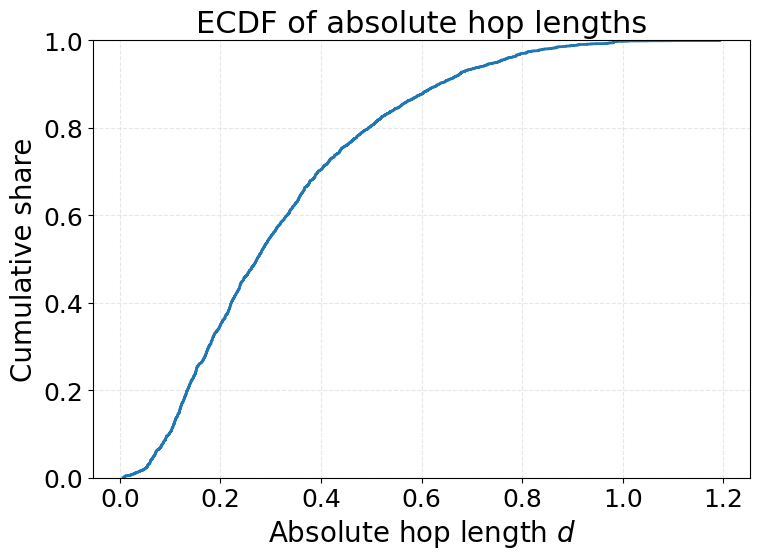

• Saved: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/ecdf_hoplength_abs_weighted.pdf


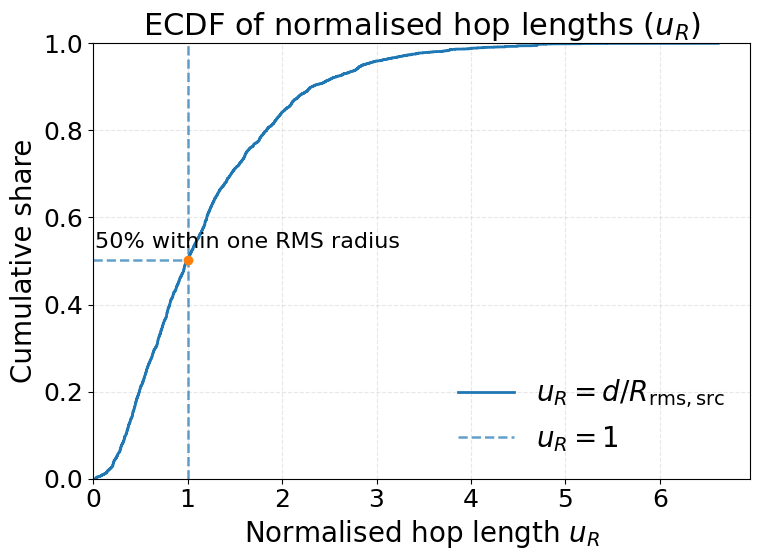

• Saved: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/ecdf_hoplength_norm_weighted_uR.pdf


In [11]:
# === Cell 10: ECDF + quantiles + fixed-threshold shares (weighted by wP), export ===
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd

mpl.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
})

W = df_tr_u["wP"].to_numpy(float)

metrics = {
    "d_xy": df_tr_u["d_xy"].to_numpy(float),
    "u_R":  df_tr_u["u_R"].to_numpy(float),
}

quantiles = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95]

# Fixed thresholds for "inverse table"
thr = [0.10, 0.25, 0.33, 0.50, 1.00, 1.50, 2.00]

def weighted_cdf_at(xs, cdf, t):
    """
    Given ECDF step function (xs sorted, cdf in [0,1]), return CDF(t) for where='post'.
    """
    if xs.size == 0:
        return np.nan
    idx = np.searchsorted(xs, t, side="right") - 1
    if idx < 0:
        return 0.0
    return float(cdf[idx])

summary_rows = []
ecdf_store = {}

# --- build ECDFs + quantile table ---
for name, X in metrics.items():
    xs, cdf = weighted_ecdf(X, W)
    ecdf_store[name] = (xs, cdf)
    summary_rows.append({
        "metric": name,
        "n_valid": int(np.isfinite(X).sum()),
        "w_sum": float(np.sum(W[np.isfinite(X) & np.isfinite(W) & (W > 0)])),
        **{f"p{int(100*q)}_w": wquantile(X, W, q) for q in quantiles},
    })

df_ecdf_summary = pd.DataFrame(summary_rows)
display(df_ecdf_summary)

# --- inverse table: shares within fixed thresholds ---
xs_R, cdf_R = ecdf_store["u_R"]
df_inv = pd.DataFrame([{
    "metric": "u_R",
    **{f"share_le_{str(t).replace('.','p')}": 100.0 * weighted_cdf_at(xs_R, cdf_R, t) for t in thr}
}])
display(df_inv)

# --- (A) Absolute hop length: d_xy ---
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)

xs, cdf = ecdf_store["d_xy"]
ax.step(xs, cdf, where="post", lw=2)
ax.set_xlabel(r"Absolute hop length $d$")
ax.set_ylabel("Cumulative share")
ax.set_ylim(0, 1.0)
ax.set_title("ECDF of absolute hop lengths")
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
fig_fp = RP.figure_fp("ecdf_hoplength_abs_weighted.pdf")
fig.savefig(fig_fp, bbox_inches="tight")
plt.show()
plt.close(fig)
infra.log("Saved:", fig_fp)

# --- (B) Normalised hop length: u_R only ---
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)

xs_R, cdf_R = ecdf_store["u_R"]
ax.step(xs_R, cdf_R, where="post", lw=2, label=r"$u_R = d / R_{\mathrm{rms,src}}$")

ax.set_xlim(left=0)
ax.set_ylim(0, 1.0)

# reference at one source-radius
x_ref = 1.0
y_at_1 = weighted_cdf_at(xs_R, cdf_R, x_ref)

ax.axvline(x_ref, lw=1.8, linestyle="--", alpha=0.7, label=r"$u_R = 1$")
ax.hlines(y_at_1, xmin=0.0, xmax=x_ref, lw=1.8, linestyle="--", alpha=0.7)
ax.plot(x_ref, y_at_1, "o", ms=6)

ax.text(
    0.02,
    y_at_1 + 0.02,
    f"{100*y_at_1:.0f}% within one RMS radius",
    ha="left",
    va="bottom",
    fontsize=16
)

ax.set_xlabel(r"Normalised hop length $u_R$")
ax.set_ylabel("Cumulative share")
ax.set_title(r"ECDF of normalised hop lengths ($u_R$)")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(frameon=False, loc="lower right")

plt.tight_layout()
fig_fp = RP.figure_fp("ecdf_hoplength_norm_weighted_uR.pdf")
fig.savefig(fig_fp, bbox_inches="tight")
plt.show()
plt.close(fig)
infra.log("Saved:", fig_fp)

• === DIAGNOSTIK: ingångsdata ===
• df_occ_onet : (878, 9)
• df_tasks_onet: (17606, 9)
• df_tr_u     : (5099, 10)
• SOC centers: (765, 4) | n_soc= 765
• SOC radii (RMS): (765, 3) | n_soc= 765
• 
=== DIAGNOSTIK: efter merge ===
•   x_src   : 5099 icke-NaN
•   y_src   : 5099 icke-NaN
•   x_tgt   : 5099 icke-NaN
•   y_tgt   : 5099 icke-NaN
•   R_src   : 5099 icke-NaN
•   R_tgt   : 5099 icke-NaN
•   d_xy    : 5099 icke-NaN
•   wP      : 5099 icke-NaN
• 
=== DIAGNOSTIK: analysunderlag ===
• Rader klara för analys: 5099
• === Normalized overlap vs hop length u_R ===
• Pearson (unweighted): -0.950
• Pearson (weighted)  : -0.945
• Share with overlap>0:  80.4%
• Saved plot → /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/overlap_vs_hop_uR.png och /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/overlap_vs_hop_uR.pdf


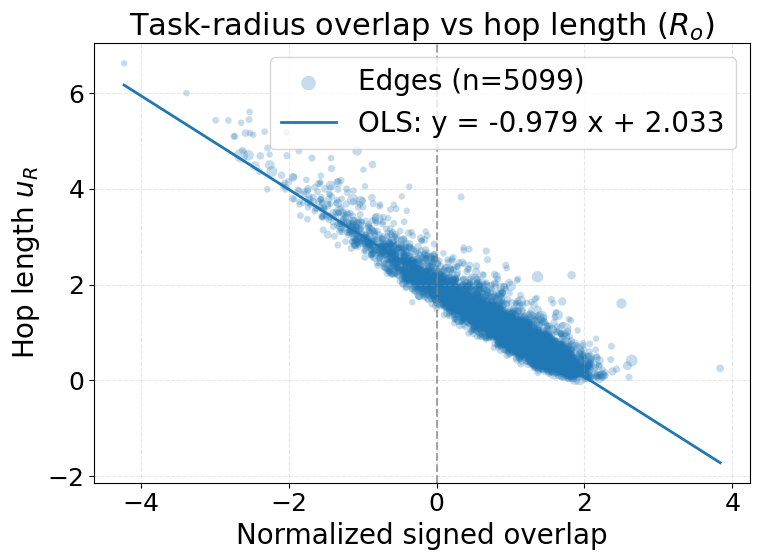

• Saved CDF → /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/overlap_cdf_uR.png och /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/overlap_cdf_uR.pdf


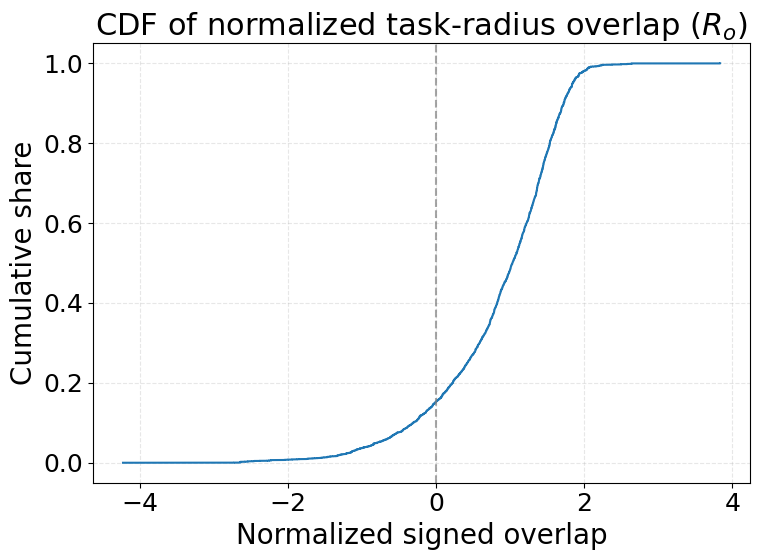

In [12]:
# === Signed overlap vs hop length (SOC2018 version; RMS-radius R_o) ===
# Förutsätter att följande finns i notebooken:
#   - df_occ_onet: O*NET-detalj occ med kolumner [onet_full, xi, chi, x, y, soc2018]
#   - df_tasks_onet: O*NET-detalj tasks med kolumner [onet_full, xi, chi, x, y, soc2018] (+ ev Task ID, is_core)
#   - df_tr_u: edge-tabell på SOC2018 med kolumner [src_soc2018, tgt_soc2018, wP, d_xy, u_R]
#   - RP (RunPaths), infra.log

from infra import RP, log
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
})

# 0) Kontrakt / sanity
need_occ   = {"onet_full", "soc2018", "x", "y"}
need_tasks = {"onet_full", "soc2018", "x", "y"}
need_tr    = {"src_soc2018", "tgt_soc2018", "d_xy", "wP"}

for name, need, df_ in [
    ("df_occ_onet", need_occ, df_occ_onet),
    ("df_tasks_onet", need_tasks, df_tasks_onet),
    ("df_tr_u", need_tr, df_tr_u),
]:
    miss = sorted(list(need - set(df_.columns)))
    if miss:
        raise KeyError(f"{name} saknar kolumner: {miss}")

if TASK_POLICY_FOR_U not in ("all", "core"):
    raise ValueError("TASK_POLICY_FOR_U must be 'all' or 'core'")

log("=== DIAGNOSTIK: ingångsdata ===")
log("df_occ_onet :", df_occ_onet.shape)
log("df_tasks_onet:", df_tasks_onet.shape)
log("df_tr_u     :", df_tr_u.shape)

def _nn(x) -> int:
    return int(np.sum(np.isfinite(pd.to_numeric(x, errors="coerce").to_numpy(float))))

# 1) SOC centers (xy): robust median över O*NET-detalj i SOC
soc_cent = (
    df_occ_onet.dropna(subset=["soc2018", "x", "y"])
              .groupby("soc2018", as_index=False)
              .agg(
                  x_soc=("x", "median"),
                  y_soc=("y", "median"),
                  n_onet=("onet_full", "nunique"),
              )
)
log("SOC centers:", soc_cent.shape, "| n_soc=", soc_cent["soc2018"].nunique())

# 2) Task radius per SOC: RMS-avstånd till O*NET-occupation-center, aggregerat robust
#    (a) task -> onet_full center
occ_cent = df_occ_onet[["onet_full", "x", "y"]].rename(columns={"x": "x_occ", "y": "y_occ"}).copy()

t = df_tasks_onet.copy()

# task-policy filter
if TASK_POLICY_FOR_U == "core" and "is_core" in t.columns:
    t = t[t["is_core"] == True].copy()

t = t.merge(occ_cent, on="onet_full", how="inner")

dx = t["x"].to_numpy(float) - t["x_occ"].to_numpy(float)
dy = t["y"].to_numpy(float) - t["y_occ"].to_numpy(float)
t["task_dist"] = np.hypot(dx, dy)
t["task_dist_sq"] = t["task_dist"] ** 2

#    (b) O*NET-radius: R_o = sqrt(mean(d^2))
radius_onet = (
    t.dropna(subset=["soc2018", "onet_full", "task_dist_sq"])
     .groupby(["soc2018", "onet_full"], as_index=False)
     .agg(
         mean_task_dist_sq=("task_dist_sq", "mean"),
         n_tasks=("task_dist_sq", "size"),
     )
)

radius_onet["R_onet"] = np.sqrt(radius_onet["mean_task_dist_sq"])

#    (c) robust SOC-radius: median över O*NET-radier inom SOC
radius_soc = (
    radius_onet.groupby("soc2018", as_index=False)
               .agg(
                   R_soc=("R_onet", "median"),
                   n_onet_used=("onet_full", "nunique"),
               )
)

log("SOC radii (RMS):", radius_soc.shape, "| n_soc=", radius_soc["soc2018"].nunique())

# 3) Merge into transitions + compute signed overlap
TR = df_tr_u[["src_soc2018", "tgt_soc2018", "d_xy", "wP"]].copy()
TR["d_xy"] = pd.to_numeric(TR["d_xy"], errors="coerce")
TR["wP"]   = pd.to_numeric(TR["wP"], errors="coerce")

trans = (
    TR
    .merge(
        soc_cent.rename(columns={"soc2018": "src_soc2018", "x_soc": "x_src", "y_soc": "y_src"}),
        on="src_soc2018", how="left"
    )
    .merge(
        soc_cent.rename(columns={"soc2018": "tgt_soc2018", "x_soc": "x_tgt", "y_soc": "y_tgt"}),
        on="tgt_soc2018", how="left"
    )
    .merge(
        radius_soc.rename(columns={"soc2018": "src_soc2018", "R_soc": "R_src"}),
        on="src_soc2018", how="left"
    )
    .merge(
        radius_soc.rename(columns={"soc2018": "tgt_soc2018", "R_soc": "R_tgt"}),
        on="tgt_soc2018", how="left"
    )
)

log("\n=== DIAGNOSTIK: efter merge ===")
for col in ["x_src", "y_src", "x_tgt", "y_tgt", "R_src", "R_tgt", "d_xy", "wP"]:
    log(f"  {col:8s}: {_nn(trans[col])} icke-NaN")

# d_centers_xy: använd d_xy om den finns/är valid, annars beräkna från x/y
if np.isfinite(trans["d_xy"].to_numpy(float)).all():
    trans["d_centers_xy"] = trans["d_xy"].to_numpy(float)
else:
    trans["d_centers_xy"] = np.hypot(
        trans["x_src"].to_numpy(float) - trans["x_tgt"].to_numpy(float),
        trans["y_src"].to_numpy(float) - trans["y_tgt"].to_numpy(float),
    )

# Signed overlap baserat på RMS-radier
trans["overlap_signed"] = (
    trans["R_src"].to_numpy(float)
    + trans["R_tgt"].to_numpy(float)
    - trans["d_centers_xy"].to_numpy(float)
)

R_src_arr = trans["R_src"].to_numpy(float)
trans["overlap_norm_src"] = np.where(
    np.isfinite(R_src_arr) & (R_src_arr > 0),
    trans["overlap_signed"].to_numpy(float) / R_src_arr,
    np.nan,
)

# 4) Analysunderlag: overlap_norm_src vs hop length u_R + vikt wP
#    Här förutsätts att df_tr_u redan innehåller u_R = d_xy / R_src
uR_col = "u_R" if "u_R" in df_tr_u.columns else "u"
if uR_col not in df_tr_u.columns:
    raise KeyError("df_tr_u måste innehålla kolumnen 'u_R' (eller temporärt 'u').")

u_map = (
    df_tr_u[["src_soc2018", "tgt_soc2018", uR_col]]
    .drop_duplicates(subset=["src_soc2018", "tgt_soc2018"])
    .set_index(["src_soc2018", "tgt_soc2018"])[uR_col]
)
trans["u_R"] = trans.set_index(["src_soc2018", "tgt_soc2018"]).index.map(u_map).to_numpy(float)

m = (
    np.isfinite(trans["overlap_norm_src"])
    & np.isfinite(trans["u_R"])
    & np.isfinite(trans["wP"])
    & (trans["wP"] > 0)
)

A = trans.loc[m, ["overlap_norm_src", "u_R", "wP"]].copy()
log("\n=== DIAGNOSTIK: analysunderlag ===")
log(f"Rader klara för analys: {len(A)}")

def weighted_corr(x: pd.Series, y: pd.Series, w: pd.Series) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    w = np.asarray(w, dtype=float)
    m2 = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > 0)
    x, y, w = x[m2], y[m2], w[m2]
    if x.size < 3:
        return float("nan")
    w = w / w.sum()
    mx, my = np.sum(w * x), np.sum(w * y)
    cov = np.sum(w * (x - mx) * (y - my))
    sx = np.sqrt(np.sum(w * (x - mx) ** 2))
    sy = np.sqrt(np.sum(w * (y - my) ** 2))
    return cov / (sx * sy) if sx > 0 and sy > 0 else float("nan")

if len(A) == 0:
    log("Inga rader kvar efter filtrering. Trolig orsak: coverage-mismatch (SOC radii eller SOC centers).")
else:
    corr_unw = A[["overlap_norm_src", "u_R"]].corr(method="pearson").iloc[0, 1]
    corr_w   = weighted_corr(A["overlap_norm_src"], A["u_R"], A["wP"])
    pos_share = float((A["overlap_norm_src"] > 0).mean())

    log("=== Normalized overlap vs hop length u_R ===")
    log(f"Pearson (unweighted): {corr_unw: .3f}")
    log(f"Pearson (weighted)  : {corr_w: .3f}")
    log(f"Share with overlap>0: {pos_share * 100: .1f}%")

    # Scatter + trend + spara
    X = A["overlap_norm_src"].to_numpy(float)
    Y = A["u_R"].to_numpy(float)
    W = A["wP"].to_numpy(float)

    fig, ax = plt.subplots(figsize=(8, 6))

    wmax = float(W.max()) if W.size else 0.0
    w_scaled = (10.0 + 90.0 * (W / wmax)) if wmax > 0 else (20.0 * np.ones_like(W))

    ax.scatter(X, Y, s=2*w_scaled, alpha=0.25, edgecolors="none", label=f"Edges (n={len(X)})")

    if X.size >= 3 and np.nanmax(X) > np.nanmin(X):
        coef = np.polyfit(X, Y, deg=1)
        xp = np.linspace(np.nanmin(X), np.nanmax(X), 200)
        yp = np.polyval(coef, xp)
        ax.plot(xp, yp, lw=2, label=f"OLS: y = {coef[0]:.3f} x + {coef[1]:.3f}")

    ax.axvline(0.0, color="gray", linestyle="--", alpha=0.7)
    ax.set_xlabel(r"Normalized signed overlap")
    ax.set_ylabel(r"Hop length $u_R$")
    ax.set_title(r"Task-radius overlap vs hop length ($R_o$)")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend(loc="best")
    plt.tight_layout()

    png_fp = RP.figures / "overlap_vs_hop_uR.png"
    pdf_fp = RP.figures / "overlap_vs_hop_uR.pdf"
    png_fp.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(png_fp, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_fp, dpi=300, bbox_inches="tight")
    log("Saved plot →", png_fp, "och", pdf_fp)
    plt.show()

    # Weighted CDF för overlap_norm_src
    vals = A["overlap_norm_src"].to_numpy(float)
    w    = A["wP"].to_numpy(float)

    order = np.argsort(vals)
    vals_sorted = vals[order]
    w_sorted    = w[order]
    w_cum       = np.cumsum(w_sorted)
    w_cum      /= w_cum[-1]

    fig_cdf, ax_cdf = plt.subplots(figsize=(8, 6))
    ax_cdf.plot(vals_sorted, w_cum, drawstyle="steps-post")

    ax_cdf.axvline(0.0, color="gray", linestyle="--", alpha=0.7)
    ax_cdf.set_xlabel(r"Normalized signed overlap")
    ax_cdf.set_ylabel("Cumulative share")
    ax_cdf.set_title(r"CDF of normalized task-radius overlap ($R_o$)")
    ax_cdf.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()

    cdf_png_fp = RP.figures / "overlap_cdf_uR.png"
    cdf_pdf_fp = RP.figures / "overlap_cdf_uR.pdf"
    cdf_png_fp.parent.mkdir(parents=True, exist_ok=True)
    fig_cdf.savefig(cdf_png_fp, dpi=300, bbox_inches="tight")
    fig_cdf.savefig(cdf_pdf_fp, dpi=300, bbox_inches="tight")
    log("Saved CDF →", cdf_png_fp, "och", cdf_pdf_fp)
    plt.show()

In [13]:
# === Cell 11: Transition quality KPIs (global + diagnostics) ===
def spearman_rank_corr(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size < 3:
        return np.nan

    rx = pd.Series(x).rank(method="average").to_numpy(dtype=float)
    ry = pd.Series(y).rank(method="average").to_numpy(dtype=float)

    rx = rx - rx.mean()
    ry = ry - ry.mean()

    den = float(np.sqrt(np.sum(rx**2) * np.sum(ry**2)))
    return float(np.sum(rx * ry) / den) if den > 0 else np.nan

edges_ok = df_tr_u[np.isfinite(df_tr_u["wP"]) & (df_tr_u["wP"] > 0) & np.isfinite(df_tr_u["d_xy"]) & (df_tr_u["d_xy"] >= 0)].copy()
w = edges_ok["wP"].to_numpy(float)
d = edges_ok["d_xy"].to_numpy(float)
u = edges_ok["u"].to_numpy(float)

kpi_global = {
    "n_edges_total": int(len(df_tr_u)),
    "n_edges_valid": int(len(edges_ok)),
    "w_sum_valid": float(np.sum(w)),
    "total_transport_wd": float(np.sum(w * d)),
    "d_mean_w": wmean(d, w),
    "d_median_w": wquantile(d, w, 0.50),
    "d_p90_w": wquantile(d, w, 0.90),
    "d_p95_w": wquantile(d, w, 0.95),
    "rho_spearman_d_w": spearman_rank_corr(d, w),
    "rho_spearman_d_log1pw": spearman_rank_corr(d, np.log1p(w)),
    "u_mean_w": wmean(u, w),
    "u_median_w": wquantile(u, w, 0.50),
    "u_p90_w": wquantile(u, w, 0.90),
    "u_p95_w": wquantile(u, w, 0.95),
    "share_u_leq_1": 100.0 * float(w[(np.isfinite(u)) & (u <= 1)].sum() / w.sum()) if w.size else np.nan,
    "share_u_leq_2": 100.0 * float(w[(np.isfinite(u)) & (u <= 2)].sum() / w.sum()) if w.size else np.nan,
    "share_u_leq_3": 100.0 * float(w[(np.isfinite(u)) & (u <= 3)].sum() / w.sum()) if w.size else np.nan,
    "rho_spearman_u_w": spearman_rank_corr(u, w),
    "rho_spearman_u_log1pw": spearman_rank_corr(u, np.log1p(w)),
    "P_THRESHOLD": float(P_THRESHOLD),
    "TOP_K": int(TOP_K),
    "TASK_POLICY_FOR_U": TASK_POLICY_FOR_U,
}

df_kpis_global = pd.DataFrame([kpi_global])
display(df_kpis_global)

out_json = {"global": df_kpis_global.iloc[0].to_dict()}
out_fp = RP.export_fp("transition_quality_kpis.json")
infra.write_json(out_fp, out_json)
infra.log("Saved:", out_fp)


,n_edges_total,n_edges_valid,w_sum_valid,total_transport_wd,d_mean_w,d_median_w,d_p90_w,d_p95_w,rho_spearman_d_w,rho_spearman_d_log1pw,...,u_p90_w,u_p95_w,share_u_leq_1,share_u_leq_2,share_u_leq_3,rho_spearman_u_w,rho_spearman_u_log1pw,P_THRESHOLD,TOP_K,TASK_POLICY_FOR_U
0,5099,5099,251.605778,80.797994,0.321129,0.272655,0.634332,0.749786,-0.141814,-0.141814,...,2.92435,3.613382,40.747812,75.059591,91.03612,-0.123487,-0.123487,0.001,25,all


• Saved: /home/joc/code/occupation-space/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports/transition_quality_kpis.json


In [14]:
# === Cell 12: Sensitivity grid (optional): KPIs over (P_THRESHOLD, TOP_K) ===
if SENS_GRID:
    rows = []
    for thr, k in SENS_GRID:
        e = build_edges(thr, k)
        ok = e[np.isfinite(e["wP"]) & (e["wP"] > 0) & np.isfinite(e["d_xy"]) & (e["d_xy"] >= 0)].copy()
        w = ok["wP"].to_numpy(float)
        d = ok["d_xy"].to_numpy(float)
        u = ok["u"].to_numpy(float)
        rows.append({
            "P_THRESHOLD": float(thr),
            "TOP_K": int(k),
            "n_edges": int(len(e)),
            "w_sum": float(np.sum(w)) if w.size else 0.0,
            "u_median_w": wquantile(u, w, 0.50),
            "share_u_leq_1": 100.0 * float(w[(np.isfinite(u)) & (u <= 1)].sum() / w.sum()) if w.size else np.nan,
            "total_transport_wd": float(np.sum(w * d)) if w.size else np.nan,
        })
    df_sens = pd.DataFrame(rows).sort_values(["P_THRESHOLD","TOP_K"]).reset_index(drop=True)
    display(df_sens)
    sens_fp = RP.export_fp("transition_sensitivity_kpis.csv")
    df_sens.to_csv(sens_fp, index=False)
    infra.log("Saved:", sens_fp)
else:
    infra.log("SENS_GRID empty: skipping sensitivity analysis.")


,P_THRESHOLD,TOP_K,n_edges,w_sum,u_median_w,share_u_leq_1,total_transport_wd
0,0.0001,3,829,123.378028,1.020725,48.893931,34.258715
1,0.0005,3,829,123.378028,1.020725,48.893931,34.258715
2,0.0010,1,282,64.381698,0.964921,54.861827,15.794212
3,0.0010,3,829,123.378028,1.020725,48.893931,34.258715
4,0.0010,5,1351,158.563858,1.068990,45.806644,46.339295
5,0.0010,10,2557,206.116098,1.144297,43.356152,63.358319
6,0.0020,3,829,123.378028,1.020725,48.893931,34.258715


• Saved: /home/joc/code/occupation-space/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports/transition_sensitivity_kpis.csv


In [15]:
# === EXPORT CELL: write plot interface files (SOC nodes + SOC edges) ===
import json
from infra import RP, log, write_csv

for name in ["df_occ_soc", "df_tr_u"]:
    if name not in globals() or globals()[name] is None:
        raise RuntimeError(f"{name} saknas – kör noder/edges-steget först.")

need_nodes = {"soc2018", "xi_soc", "chi_soc"}
miss_nodes = sorted(need_nodes - set(df_occ_soc.columns))
if miss_nodes:
    raise ValueError(f"df_occ_soc saknar kolumner: {miss_nodes}")

need_edges = {"src_soc2018", "tgt_soc2018", "wP"}
miss_edges = sorted(need_edges - set(df_tr_u.columns))
if miss_edges:
    raise ValueError(f"df_tr_u saknar kolumner: {miss_edges}")

# ----------------------------
# 1) Nodes export
# ----------------------------
nodes = df_occ_soc.copy()

colmap_optional = {
    "n_onet_detailed": "n_support",
}
keep_optional = [c for c in colmap_optional.keys() if c in nodes.columns]

nodes_out = nodes[["soc2018", "xi_soc", "chi_soc"] + keep_optional].copy()
nodes_out = nodes_out.rename(columns={
    "soc2018": "node_id",
    "xi_soc": "xi",
    "chi_soc": "chi",
    **{k: v for k, v in colmap_optional.items() if k in keep_optional},
})

nodes_out["node_id"] = nodes_out["node_id"].astype(str)
nodes_out["xi"] = nodes_out["xi"].astype(float)   # radians under the hood
nodes_out["chi"] = nodes_out["chi"].astype(float)

# ----------------------------
# 2) Edges export
# ----------------------------
edges = df_tr_u.copy()

edge_optional = [
    "d_xy",
    "u",
    "med_src_task_dist",
    "P_THRESHOLD",
    "TOP_K",
    "TASK_POLICY_FOR_U",
]
keep_edge_optional = [c for c in edge_optional if c in edges.columns]

edges_out = edges[["src_soc2018", "tgt_soc2018", "wP"] + keep_edge_optional].copy()
edges_out = edges_out.rename(columns={
    "src_soc2018": "src_id",
    "tgt_soc2018": "tgt_id",
    "wP": "weight",
})

edges_out["src_id"] = edges_out["src_id"].astype(str)
edges_out["tgt_id"] = edges_out["tgt_id"].astype(str)
edges_out["weight"] = edges_out["weight"].astype(float)

# ----------------------------
# 3) Write files
# ----------------------------
fp_nodes = RP.export_fp("plot_nodes.csv")
fp_edges = RP.export_fp("plot_edges.csv")
fp_meta  = RP.export_fp("plot_meta.json")

write_csv(fp_nodes, nodes_out)
write_csv(fp_edges, edges_out)

meta = {
    "node_type": "soc2018",
    "xi_unit": "radians",
    "primary_edge_weight": "weight",
    "notes": "plot interface for network/region polar plots; ids must match between nodes and edges",
}
fp_meta.write_text(json.dumps(meta, indent=2), encoding="utf-8")

log("Wrote plot nodes:", fp_nodes, "shape=", nodes_out.shape)
log("Wrote plot edges:", fp_edges, "shape=", edges_out.shape)
log("Wrote plot meta :", fp_meta)


• Wrote plot nodes: /home/joc/code/occupation-space/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports/plot_nodes.csv shape= (765, 4)
• Wrote plot edges: /home/joc/code/occupation-space/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports/plot_edges.csv shape= (5099, 8)
• Wrote plot meta : /home/joc/code/occupation-space/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports/plot_meta.json
